# Propensity Score Calculation and Matching

Este notebook calcula el propensity score para cada unidad de la cuadrícula y realiza el matching entre unidades tratadas (con cámara) y de control (sin cámara). Evalúa la calidad del matching mediante Standardized Mean Difference (SMD) antes y después del matching, y genera visualizaciones comparativas.

**Inputs necesarios:**
- `grid-propensity-score-features.parquet`: Features para el cálculo del propensity score
- `grid.parquet`: Cuadrícula espacial con las unidades de análisis
- `outcome-variables.parquet`: Variables de resultado (accidentes) por grid y tiempo

**Outputs generados:**
- `matched-grids.parquet`: Grids que fueron emparejados (tratados y controles)
- `graphs/smd-before-after-matching.png`: Gráfico de comparación de SMD antes y después del matching
- `graphs/tasa-accidentes-control-tratamiento.png`: Gráfico de tasas de accidentes para grupos de tratamiento y control a lo largo del tiempo

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression

warnings.filterwarnings("ignore")
PATH_DATA = '../../data/'
GRID_SIZE = 123

In [2]:
features = pd.read_parquet(os.path.join(PATH_DATA, "grid-propensity-score-features.parquet"))
grid = gpd.read_feather(os.path.join(PATH_DATA, "grid.parquet"))
outcome = pd.read_parquet(os.path.join(PATH_DATA, "outcome-variables.parquet"))

In [3]:
# Descripción general de los datos
treated = features.query('has_camera == 1')
control = features.query('has_camera == 0')
print(f"Unidades totales: {features.shape[0]}")
print(f"Unidades tratadas: {treated.shape[0]}")
print(f"Unidades sin tratar: {control.shape[0]}")

Unidades totales: 3073
Unidades tratadas: 97
Unidades sin tratar: 2976


### Calcular el propensity score

In [44]:
# Por alguna razón, el matching es muchísimo mejor si no considero 
# todas estas variables para el cálcuclo del propensity score.
# En la literatura hay evidencia de que el propensity score
# solo es una manera de hacer que el matching sea sencillo,
# y no es tan relevante las variables que se hayan usado,
# siempre y cuando el matching sea bueno, lo cual se puede ver
# viendo la SMD al final, y el quitar esto minimiza el smd de 
# todas las variables, incluyendo estas que estoy quitando

drop_columns_dict = {
    123:[ # 300 m
        "mean_min", "std_min",
        "max_carriles",
        "via_primaria",
        "via_acc_cont",
        "both_directions"
    ],
    185:[ # 200 m
        "max_carriles",
        "via_acc_cont",
        "both_directions",
        "n_vialidades"
    ],
    368:[ # 100 m
        "max_carriles",
        "via_primaria",
        "via_acc_cont",
        "both_directions",
        "n_vialidades"
    ],
    500:[ # 75 m
        "mean_min", "std_min",
        "mean_fcs", "std_fcs",
        "max_carriles",
        "via_primaria",
        "via_acc_cont",
        "both_directions",
        "n_vialidades"
    ]
}

drop_columns = drop_columns_dict[GRID_SIZE]

lr = LogisticRegression()

x = features.drop(drop_columns, axis=1).set_index('grid_id').drop(columns=['has_camera']).values
y = features.has_camera.values

lr.fit(X=x, y=y)

propensity_score = (
    features
    .assign(propensity_score = lr.predict_proba(x)[:,1])
    [['grid_id', 'propensity_score', 'has_camera']]
)

### Matching

In [5]:
def propensity_score_matching(
    treated_df: pd.DataFrame,
    control_df: pd.DataFrame,
    method: str = "nearest",  # options: "nearest", "caliper"
    n_matches: int = 1,
    replace: bool = True,
    caliper: float = 0.05  # used only if method="caliper"
) -> dict:
    """
    Returns for each treated unit the best matches in the control group,
    based on propensity score distance.

    Parameters
    ----------
    treated_df : pd.DataFrame with columns ["grid_id", "propensity_score"]
    control_df : pd.DataFrame with columns ["grid_id", "propensity_score"]
    method : "nearest" | "caliper"
    n_matches : int, number of matches for each treated unit
    replace : bool, if True, controls can be matched more than once
    caliper : float, maximum allowed distance if using caliper matching

    Returns
    -------
    matches_dict : dict {treated_grid_id: [matched_control_grid_ids]}
    """

    # Pre-extract arrays for speed
    treat_ids = treated_df["grid_id"].values
    treat_scores = treated_df["propensity_score"].values
    ctrl_ids = control_df["grid_id"].values
    ctrl_scores = control_df["propensity_score"].values

    matches = {}

    # To track which controls have been used if no replacement
    available = np.ones(len(ctrl_ids), dtype=bool)

    for i, (tid, tscore) in enumerate(zip(treat_ids, treat_scores)):
        # Distances to all available controls
        distances = np.abs(ctrl_scores - tscore)
        if not replace:
            distances = np.where(available, distances, np.inf)
        if method == "nearest":
            idx = np.argsort(distances)[:n_matches]
            selected_ctrl = ctrl_ids[idx]
            matches[tid] = selected_ctrl.tolist()
            if not replace:
                available[idx] = False  # Mark them as used
        elif method == "caliper":
            # Only controls within caliper
            eligible = (distances <= caliper)
            eligible_idx = np.where(eligible)[0]
            if len(eligible_idx) == 0:
                matches[tid] = []  # No match found
                continue
            # Among eligible, pick n_matches nearest
            eligible_distances = distances[eligible_idx]
            order = np.argsort(eligible_distances)[:n_matches]
            selected_ctrl = ctrl_ids[eligible_idx[order]]
            matches[tid] = selected_ctrl.tolist()
            if not replace:
                available[eligible_idx[order]] = False
        else:
            raise ValueError("method must be 'nearest' or 'caliper'.")

    return matches

In [6]:
control = propensity_score[propensity_score.has_camera == 0]
treated = propensity_score[propensity_score.has_camera == 1]

matching = propensity_score_matching(
    treated_df=treated,
    control_df=control,
    method='nearest',
    n_matches=1,
    replace=False
)

# Filtramos solo aquellos grids que sí están matched
matched_grid_ids = list(matching.keys()) + [x for values in matching.values() for x in values]
matched_grids = features[features.grid_id.isin(matched_grid_ids)]

In [7]:
# Para demostrar que vienen de distribuciones distintas 
# se pueden hacer las siguientes pruebas dependiendo del tipo de variable.
variables_continuas = [
    "mean_afluencia_mensual", # afluencia media mensual escalada en la estación de metro más cercana
    "std_afluencia_mensual", # standardized deviation of afluencia mensual
    "distance_to_station", # distancia escalada a la estación de metro más cercana
    "mean_total", # media de accidentes mensuales en cada grid
    "std_total", # standardized deviation of monthly accidents
    "mean_min", # media mensual de accidentes sin lesionados
    "std_min", # std of monthly accidents sin lesionados
    "mean_pic", # media mensual de accidentes con lesiones menores
    "std_pic", # std of monthly accidents con lesionados menores
    "mean_fcs", # media mensual de accidentes con fatalidades
    "std_fcs", # std of monthly accidents con fatalidades
]

variables_discretas_ordinales = [
    "n_vialidades", # número de vialidades,
    "max_carriles", # número máximo de carriles de las vialidades dentro de la unidad
    "max_nivel", # nivel máximo de las vialidades dentro de la unidad (eg. segundo piso de periférico sería 2)
]

variables_binarias = [
    "both_directions", # si existen o no vialidades de doble sentido dentro de la unidad
    "via_primaria", # si existen o no vías primarias en la unidad
    "via_acc_cont", # si existen o no vías de acceso controlado dentro de la unidad
]

In [8]:
def smd(
    treated: np.ndarray, 
    control: np.ndarray
) -> float:
    """
    Compute the Standardized Mean Difference (SMD) between two groups.
    
    La SMD sirve para medir el tamaño del desbalance 
    cuando la variable es continua o binaria.

    SMD < 0.1 implica buen balance, y no depende del tamaño de la muestra. 
    
    
    Parameters:
        treated (np.ndarray): Array of values for the treated group
        control (np.ndarray): Array of values for the control group
        
    Returns:
        float: SMD value
    """
    treated = np.asarray(treated, dtype=float)
    control = np.asarray(control, dtype=float)

    # Means
    mean_t = np.mean(treated)
    mean_c = np.mean(control)
    
    # Standard deviations
    sd_t = np.std(treated, ddof=1)
    sd_c = np.std(control, ddof=1)
    
    # Pooled standard deviation
    pooled_sd = np.sqrt((sd_t**2 + sd_c**2) / 2)
    
    # SMD
    if pooled_sd == 0:
        return np.nan  # Avoid division by zero
    
    return (mean_t - mean_c) / pooled_sd

In [9]:
# Ahora respondemos la pregunta: 
# ¿cómo eran distintas las variables antes y después del matching?
# Previo matching
def clean_variable(s:str):
    return s.replace('_', ' ').title()
smd_values = []

treated_bm = features[features.has_camera == 1]
control_bm = features[features.has_camera == 0]

for variable in (
    variables_continuas 
    + variables_discretas_ordinales 
    + variables_binarias
):
    var_smd = smd(
        treated=treated_bm[variable].values,
        control=control_bm[variable].values
    )
    
    smd_values.append({
        'variable':clean_variable(variable),
        'smd':var_smd,
        'before_matching':True
    })
    
# Y ahora lo calculamos para las unidades tras hacer el matching
treated_am = matched_grids[matched_grids.has_camera == 1]
control_am = matched_grids[matched_grids.has_camera == 0]

for variable in (
    variables_continuas 
    + variables_discretas_ordinales 
    + variables_binarias
):
    var_smd = smd(
        treated=treated_am[variable].values,
        control=control_am[variable].values
    )
    
    smd_values.append({
        'variable':clean_variable(variable),
        'smd':var_smd,
        'before_matching':False
    })
    
smd_df = pd.DataFrame(smd_values)

In [10]:
print(f"Mean smd: {smd_df.query('~before_matching').smd.abs().mean()}")
print(f"Sum smd: {smd_df.query('~before_matching').smd.abs().sum()}")

Mean smd: 0.08534996064906519
Sum smd: 1.4509493310341082


In [11]:
def double_love_plot(
    df_before, 
    df_after, 
    variable_col="variable", 
    smd_col="smd",
    label_before="Before matching", 
    label_after="After matching",
    figsize=(7, 8), 
    threshold=0.1
):

    # Merge both dataframes on variable name
    merged = pd.merge(
        df_before[[variable_col, smd_col]],
        df_after[[variable_col, smd_col]],
        on=variable_col,
        suffixes=("_before", "_after")
    )

    # Optional: sort by maximum absolute SMD
    merged = merged.copy()
    merged["max_abs_smd"] = merged[[f"{smd_col}_before", f"{smd_col}_after"]].abs().max(axis=1)
    merged = merged.sort_values("max_abs_smd", ascending=True)
    
    y_labels = merged[variable_col]
    y_pos = range(len(merged))


    fig, ax = plt.subplots(figsize=figsize)

    # --- Add dotted lines between before and after ---
    
    for i, row in merged.iterrows():
        value_before = row[f"{smd_col}_before"]
        value_after = row[f"{smd_col}_after"]
        better = abs(value_before) > abs(value_after)

        plt.plot(
            [value_before, value_after],
            [list(y_pos)[merged.index.get_loc(i)]] * 2,
            linestyle="-",
            color="black" if better else "red",
            alpha=1,
            linewidth=1,
            zorder=1
        )

    # Before matching: circles
    plt.scatter(
        merged[f"{smd_col}_before"], y_pos, 
        color="white", edgecolor="black",
        s=80, marker="o", label=label_before, alpha=1, linewidth=1, zorder=10
    )

    # After matching: circles
    plt.scatter(
        merged[f"{smd_col}_after"], y_pos, 
        color=sns.color_palette("rocket")[0],
        s=80, marker="o", label=label_after, alpha=1, zorder=12
    )
    
    # Reference lines
    plt.axvline(0, color="k", linewidth=1)
    plt.axvline(threshold, color="gray", linestyle="--", lw=1)
    plt.axvline(-threshold, color="gray", linestyle="--", lw=1)

    plt.yticks(y_pos, y_labels)
    plt.xlabel("Standardized Mean Difference (SMD)")
    plt.title("SMD Comparison")
    plt.legend(loc="upper left", frameon=False)
    plt.grid(axis="y", linestyle=":", alpha=0.3, zorder=-20)
    fig.tight_layout()
    plt.show()
    return fig

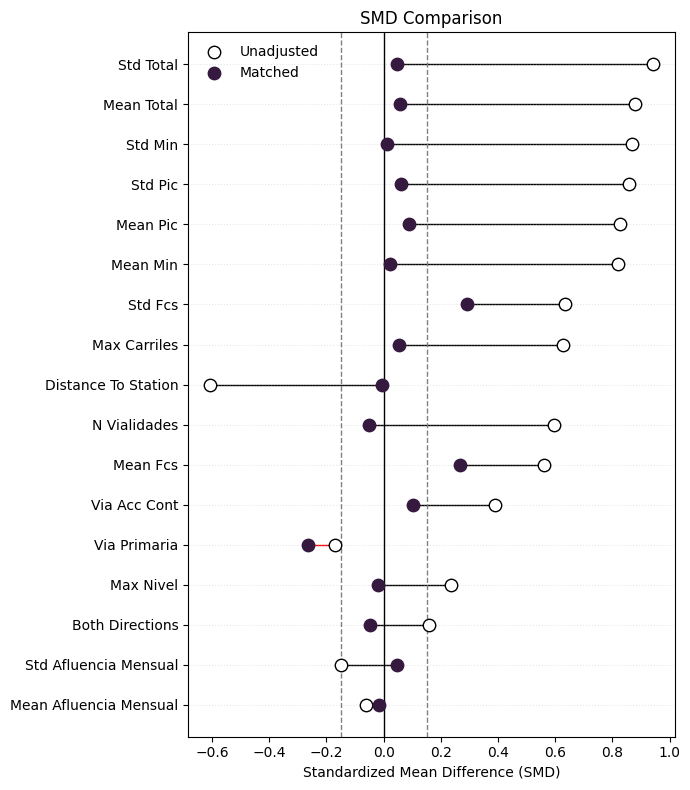

In [12]:
plot = double_love_plot(
    df_before=smd_df.query('before_matching'),
    df_after=smd_df.query('~before_matching'),
    variable_col='variable',
    smd_col='smd',
    threshold=.15,
    label_before="Unadjusted",
    label_after="Matched"
)
plot.savefig(os.path.join(PATH_DATA, "graphs", "smd-before-after-matching.png"), dpi=350, transparent=True)
plt.show()

In [13]:
# Y ahora grafiquemos las tendencias de los grupos en tasas de accidentes
# Vamos a calcular el promedio de la tasa de accidentes para las unidades tratadas, 
# y el promedio de las tasas de accidentes para los grids sin tratamiento

treated_ids = matched_grids[matched_grids.has_camera == 1].grid_id.values
control_ids = matched_grids[matched_grids.has_camera == 0].grid_id.values

pdf = (
    outcome
    .merge(matched_grids[["grid_id", "has_camera"]], on='grid_id')
    .assign(
        grid_type=lambda x: x.has_camera.map({0:"control", 1:"treatment"})
    )
    .pivot_table(
        index=["timestamp", "volumen_mensual"],
        columns="grid_type",
        values="total",
        aggfunc="sum"
    )
    .reset_index()
    .assign(
        control=lambda x: x.control/x.volumen_mensual,
        treatment=lambda x: x.treatment/x.volumen_mensual,
        change=lambda x: x.treatment / x.control - 1
    )
    .drop("volumen_mensual", axis=1)
    .set_index('timestamp')
    .sort_index()
)

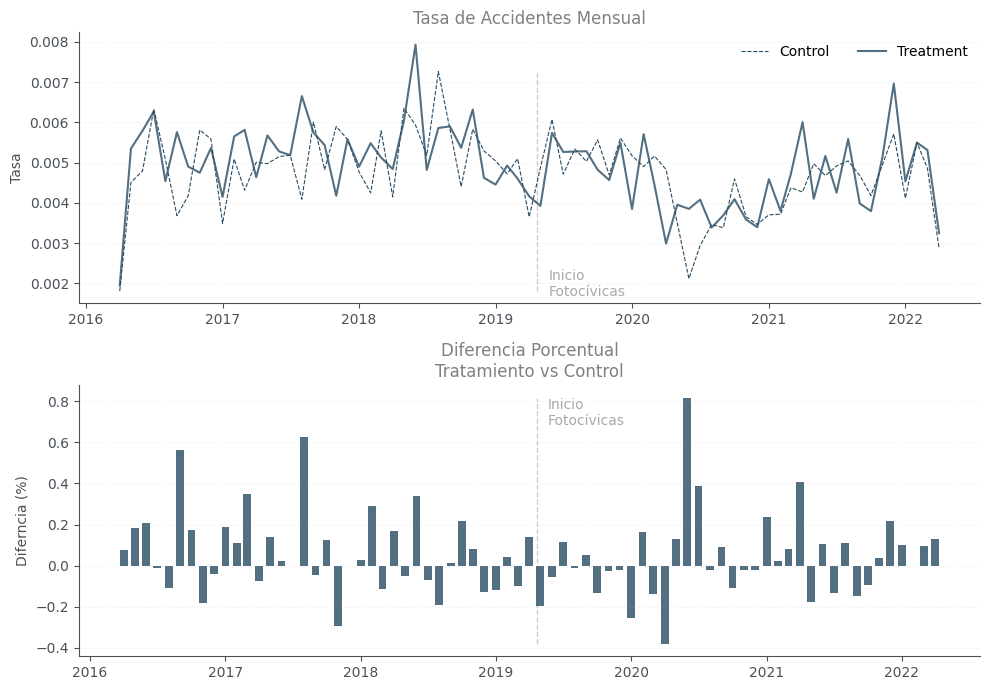

In [34]:
fig, axes = plt.subplots(2,1, figsize=(10,7))

def clean_ax(ax):
    ax.spines.top.set_visible(False)
    ax.spines.right.set_visible(False)

    axis_color = "#495057"
    ax.xaxis.label.set_color(axis_color)
    ax.yaxis.label.set_color(axis_color)
    ax.spines.bottom.set_color(axis_color)
    ax.spines.left.set_color(axis_color)
    ax.tick_params(axis='both', colors=axis_color)
    ax.grid(axis='y', alpha=.2, linestyle=':')

ax = axes[0]
clean_ax(ax)

ax.plot(
    pdf.index,
    pdf.control,
    color='#284b63',
    label='Control',
    linewidth=.8,
    linestyle='--'
)

ax.plot(
    pdf.index,
    pdf.treatment,
    color='#284b63',
    linewidth=1.5,
    alpha=.8,
    label='Treatment'
)

min_y = pdf.control.min()
max_y = pdf.control.max()
ax.vlines(
    x=pd.to_datetime("2019-04-22"), 
    ymin=min_y, ymax=max_y, 
    zorder=-10, color="gray", 
    linestyles="dashed", 
    linewidth=1, alpha=.4
)

ax.legend(ncols=2, frameon=False)
ax.annotate(
    "Inicio\nFotocívicas", 
    xy=(pd.to_datetime("2019-05-22"), min_y + (max_y-min_y)*.1), 
    ha="left", 
    va="top", 
    color="darkgray"
)
ax.set_title("Tasa de Accidentes Mensual", color='gray')
ax.set_ylabel("Tasa")

ax = axes[1]
clean_ax(ax)

delta = (pdf.index[1] - pdf.index[0]).days
width = delta * 0.7

ax.bar(
    pdf.index,
    pdf.change,
    width=width,
    align='center',
    color='#284b63',
    alpha=.8
)

min_y = pdf.change.min()
max_y = pdf.change.max()
ax.vlines(
    x=pd.to_datetime("2019-04-22"), 
    ymin=min_y, ymax=max_y, 
    zorder=-10, color="gray", 
    linestyles="dashed", 
    linewidth=1, alpha=.4
)
ax.annotate(
    "Inicio\nFotocívicas", 
    xy=(pd.to_datetime("2019-05-22"), max_y), 
    ha="left", 
    va="top", 
    color="darkgray"
)

ax.set_title("Diferencia Porcentual\nTratamiento vs Control", color='gray')
ax.set_ylabel("Diferncia (%)")

fig.tight_layout()
fig.savefig(os.path.join(PATH_DATA, "graphs", "tasa-accidentes-control-tratamiento.png"), dpi=350, transparent=True)
plt.show()

In [15]:
# Guardamos el matching
(
    matched_grids
    [['grid_id', 'has_camera']]
    .reset_index(drop=True)
    .to_parquet(os.path.join(PATH_DATA, "matched-grids.parquet"), index=False)
)